# 3-bit repetition code — trivial compiler pass

This notebook demonstrates a compiler pass that encodes every logical
qubit as three physical qubits and protects single-qubit Clifford
operations by triplicating them. Each measurement is followed by a
classical **majority vote** decoder (`qstack.decode @majority_vote`).

The pass is intentionally minimal: it is a faithful MLIR port of the
legacy `src/qstack/compilers/rep3_trivial.py` and serves as a worked
example of a compiler pass on `qstack` IR.

## 1. A tiny logical program

We prepare $|1\rangle$ by applying `X` to $|0\rangle$ and measure it. In
the unprotected program one `X` gate is enough — but if any gate is
followed by a bit-flip, the measurement is wrong with probability 1.

In [1]:
%load_ext qstack_mlir.jupyter

In [2]:
%%qasm logical
QSTACKQASM 0.1;
include "qstack/cliffords.inc";

qreg q[1];
creg c[1];
x q[0];
measure q[0] -> c[0];

<ModuleOp 4491339984(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4566199920>], parent=None, _next_op=None, _prev_op=None)>

In [3]:
print(logical)

builtin.module {
  func.func @main() -> !qstack.bit {
    %0 = qstack.kernel {
    ^bb0(%1: !qstack.qubit):
      %2 = "cliffords.x"(%1) : (!qstack.qubit) -> !qstack.qubit
      %3 = qstack.measure %2
      qstack.return %3 : !qstack.bit
    } : () -> !qstack.bit
    func.return %0 : !qstack.bit
  }
}


## 2. Compile with the 3-bit repetition pass

`compile_rep3` rewrites the module:

- every `!qstack.qubit` value becomes **three** physical qubits,
- every single-qubit Clifford (`H`, `X`, `Z`, `S`) is applied
  transversally on each of the three copies,
- every `qstack.measure` becomes three measurements followed by a
  `qstack.decode @majority_vote` outside the kernel boundary.

Compare the printed IR to the logical version above.

In [4]:
from qstack_mlir.passes.rep3_trivial import compile_rep3, register_rep3_callbacks

encoded = compile_rep3(logical)
print(encoded)

builtin.module {
  func.func @main() -> !qstack.bit {
    %0, %1, %2 = qstack.kernel {
    ^bb0(%3: !qstack.qubit, %4: !qstack.qubit, %5: !qstack.qubit):
      %6 = "cliffords.x"(%3) : (!qstack.qubit) -> !qstack.qubit
      %7 = "cliffords.x"(%4) : (!qstack.qubit) -> !qstack.qubit
      %8 = "cliffords.x"(%5) : (!qstack.qubit) -> !qstack.qubit
      %9 = qstack.measure %6
      %10 = qstack.measure %7
      %11 = qstack.measure %8
      qstack.return %9, %10, %11 : !qstack.bit, !qstack.bit, !qstack.bit
    } : () -> !qstack.bit, !qstack.bit, !qstack.bit
    %12 = "qstack.decode"(%0, %1, %2) <{callee = @majority_vote}> : (!qstack.bit, !qstack.bit, !qstack.bit) -> !qstack.bit
    func.return %12 : !qstack.bit
  }
  func.func private @majority_vote(!qstack.bit, !qstack.bit, !qstack.bit) -> !qstack.bit attributes {qstack.decoder}
}


## 3. Run the encoded program

The encoded module still surfaces a single classical bit through `main`.
We register the `majority_vote` decoder on a `CallbackRegistry` and run
1000 shots — every shot should return `[1]`.

In [5]:
from qstack_mlir.runtime import CallbackRegistry, Machine

reg = CallbackRegistry()
register_rep3_callbacks(reg)

machine = Machine(encoded, num_qubits=4, registry=reg)
results = machine.shots("main", 1000)
results

Results(1000 shots, histogram={(1,): 1000})

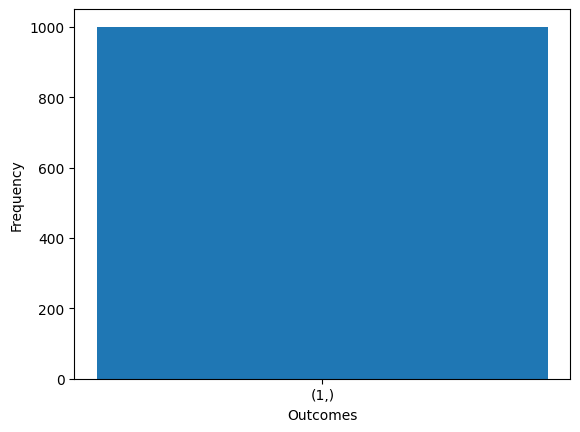

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [6]:
results.plot_histogram()

## 4. The pass is composable

`compile_rep3` takes a `ModuleOp` and returns a `ModuleOp`, so applying
it again to its own output yields a **concatenated** 9-qubit code: every
one of the three physical qubits gets triplicated, and the three
inner majority-vote decoders feed a fourth majority-vote decoder that
produces the final logical bit.

In [7]:
encoded2 = compile_rep3(encoded)
print(encoded2)

builtin.module {
  func.func @main() -> !qstack.bit {
    %0, %1, %2, %3, %4, %5, %6, %7, %8 = qstack.kernel {
    ^bb0(%9: !qstack.qubit, %10: !qstack.qubit, %11: !qstack.qubit, %12: !qstack.qubit, %13: !qstack.qubit, %14: !qstack.qubit, %15: !qstack.qubit, %16: !qstack.qubit, %17: !qstack.qubit):
      %18 = "cliffords.x"(%9) : (!qstack.qubit) -> !qstack.qubit
      %19 = "cliffords.x"(%10) : (!qstack.qubit) -> !qstack.qubit
      %20 = "cliffords.x"(%11) : (!qstack.qubit) -> !qstack.qubit
      %21 = "cliffords.x"(%12) : (!qstack.qubit) -> !qstack.qubit
      %22 = "cliffords.x"(%13) : (!qstack.qubit) -> !qstack.qubit
      %23 = "cliffords.x"(%14) : (!qstack.qubit) -> !qstack.qubit
      %24 = "cliffords.x"(%15) : (!qstack.qubit) -> !qstack.qubit
      %25 = "cliffords.x"(%16) : (!qstack.qubit) -> !qstack.qubit
      %26 = "cliffords.x"(%17) : (!qstack.qubit) -> !qstack.qubit
      %27 = qstack.measure %18
      %28 = qstack.measure %19
      %29 = qstack.measure %20
      %30 = qs

Notice the structure in the printed IR:

- the kernel now allocates **9** physical qubits and emits **9** `X`
  gates and **9** measurements,
- three `qstack.decode @majority_vote` ops collapse the bits in groups
  of three,
- a final `qstack.decode @majority_vote` collapses those three results
  into the single bit returned from `main`.

We can run the concatenated program with the same `majority_vote`
callback — no new registrations needed.

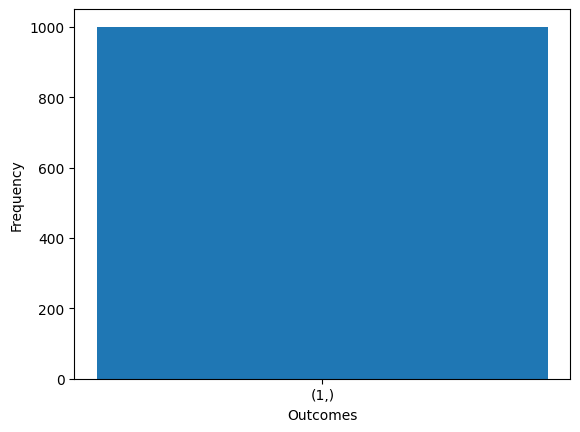

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [8]:
machine2 = Machine(encoded2, num_qubits=16, registry=reg)
results2 = machine2.shots("main", 1000)
results2.plot_histogram()

Same pass, applied twice, same callback registry, same `Machine` — the
pipeline is just function composition over `ModuleOp`. This is the
pattern future fault-tolerant schemes (Steane, surface codes) will
follow.